# 0050 vs 006208 相對價值策略

### 環境與套件

In [317]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

PROJECT_ROOT

WindowsPath('C:/Users/USER/Desktop/ETF-alpha-lab')

### 讀取 ETF daily panel

In [318]:
PANEL_PATH = PROJECT_ROOT / "data" / "processed" / "etf_daily_panel.csv"

panel = pd.read_csv(
    PANEL_PATH,
    dtype={"symbol": str},
)

panel["date"] = pd.to_datetime(panel["date"])
panel["symbol"] = panel["symbol"].astype(str)

panel = panel.sort_values(["symbol", "date"]).reset_index(drop=True)

print("Shape:", panel.shape)
print("Date range:", panel["date"].min(), "to", panel["date"].max())
print("Symbols:", sorted(panel["symbol"].unique()))

panel.head()

Shape: (5609, 19)
Date range: 2024-01-02 00:00:00 to 2026-05-18 00:00:00
Symbols: ['0050', '0052', '0056', '006208', '00713', '00878', '00919', '00929', '00939', '00940']


,date,symbol,open,high,low,close,adj_close,volume,nav,prev_nav,nav_change,nav_change_pct,market_price,premium_discount,close_to_nav,market_price_to_nav,close_ret,nav_ret,price_nav_ret_spread
0,2024-01-02,0050,33.900002,33.987499,33.662498,33.724998,31.668650,23688304,135.45,136.20,-0.75,-0.0055,134.90,-0.0041,-0.751015,-0.004061,NaN,NaN,NaN
1,2024-01-03,0050,33.424999,33.474998,33.075001,33.137501,31.116974,54189900,132.66,135.45,-2.79,-0.0206,132.55,-0.0008,-0.750207,-0.000829,-0.017420,-0.020598,0.003178
2,2024-01-04,0050,33.137501,33.187500,33.075001,33.125000,31.105234,18270372,132.86,132.66,0.20,0.0015,132.50,-0.0027,-0.750677,-0.002710,-0.000377,0.001508,-0.001885
3,2024-01-05,0050,33.137501,33.237499,33.025002,33.037498,31.023071,15998684,132.22,132.86,-0.64,-0.0048,132.15,-0.0005,-0.750132,-0.000529,-0.002642,-0.004817,0.002176
4,2024-01-08,0050,33.250000,33.400002,33.187500,33.187500,31.163923,37578880,133.01,132.22,0.79,0.0060,132.75,-0.0020,-0.750489,-0.001955,0.004540,0.005975,-0.001435


### 設定研究參數

In [319]:
symbol_a = "0050"
symbol_b = "006208"

start_date = "2024-01-01"
end_date = None

price_col = "adj_close"

beta_window = 60
z_window = 20
entry_z = 2.5
exit_z = 0.3
fee_rate = 0.0008

sizing_mode = "dollar_neutral"  # or "beta_neutral"

### 取出 0050 / 006208 並整理成寬表

In [320]:
pair = panel[panel["symbol"].isin([symbol_a, symbol_b])].copy()

pair = pair[pair["date"] >= pd.to_datetime(start_date)].copy()

if end_date is not None:
    pair = pair[pair["date"] <= pd.to_datetime(end_date)].copy()

required_cols = [
    "date",
    "symbol",
    price_col,
    "close",
    "nav",
    "premium_discount",
    "volume",
]

missing_cols = [col for col in required_cols if col not in pair.columns]

if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")

pair.head()

,date,symbol,open,high,low,close,adj_close,volume,nav,prev_nav,nav_change,nav_change_pct,market_price,premium_discount,close_to_nav,market_price_to_nav,close_ret,nav_ret,price_nav_ret_spread
0,2024-01-02,0050,33.900002,33.987499,33.662498,33.724998,31.668650,23688304,135.45,136.20,-0.75,-0.0055,134.90,-0.0041,-0.751015,-0.004061,NaN,NaN,NaN
1,2024-01-03,0050,33.424999,33.474998,33.075001,33.137501,31.116974,54189900,132.66,135.45,-2.79,-0.0206,132.55,-0.0008,-0.750207,-0.000829,-0.017420,-0.020598,0.003178
2,2024-01-04,0050,33.137501,33.187500,33.075001,33.125000,31.105234,18270372,132.86,132.66,0.20,0.0015,132.50,-0.0027,-0.750677,-0.002710,-0.000377,0.001508,-0.001885
3,2024-01-05,0050,33.137501,33.237499,33.025002,33.037498,31.023071,15998684,132.22,132.86,-0.64,-0.0048,132.15,-0.0005,-0.750132,-0.000529,-0.002642,-0.004817,0.002176
4,2024-01-08,0050,33.250000,33.400002,33.187500,33.187500,31.163923,37578880,133.01,132.22,0.79,0.0060,132.75,-0.0020,-0.750489,-0.001955,0.004540,0.005975,-0.001435


### Pivot 成策略研究表

In [321]:
price = pair.pivot(index="date", columns="symbol", values=price_col)
close = pair.pivot(index="date", columns="symbol", values="close")
nav = pair.pivot(index="date", columns="symbol", values="nav")
premium = pair.pivot(index="date", columns="symbol", values="premium_discount")
volume = pair.pivot(index="date", columns="symbol", values="volume")


data = pd.DataFrame(index=price.index)

data[f"price_{symbol_a}"] = price[symbol_a]
data[f"price_{symbol_b}"] = price[symbol_b]

data[f"close_{symbol_a}"] = close[symbol_a]
data[f"close_{symbol_b}"] = close[symbol_b]

data[f"nav_{symbol_a}_raw"] = nav[symbol_a]
data[f"nav_{symbol_b}_raw"] = nav[symbol_b]

data[f"premium_{symbol_a}"] = premium[symbol_a]
data[f"premium_{symbol_b}"] = premium[symbol_b]

data[f"volume_{symbol_a}"] = volume[symbol_a]
data[f"volume_{symbol_b}"] = volume[symbol_b]

data = data.sort_index()

print("Before NAV adjustment:")
print(data.shape)
data.head()

Before NAV adjustment:
(571, 10)


,price_0050,price_006208,close_0050,close_006208,nav_0050_raw,nav_006208_raw,premium_0050,premium_006208,volume_0050,volume_006208
date,,,,,,,,,,
2024-01-02,31.668650,73.336761,33.724998,76.900002,135.45,77.25,-0.0041,-0.0045,23688304,2839850
2024-01-03,31.116974,72.096985,33.137501,75.599998,132.66,75.65,-0.0008,-0.0007,54189900,6382057
2024-01-04,31.105234,72.049309,33.125000,75.550003,132.86,75.77,-0.0027,-0.0029,18270372,2976905
2024-01-05,31.023071,71.858566,33.037498,75.349998,132.22,75.40,-0.0005,-0.0007,15998684,2577533
2024-01-08,31.163923,72.383087,33.187500,75.900002,133.01,75.84,-0.0020,0.0008,37578880,4169890


### 調整 0050 NAV 分割

In [322]:
def adjust_nav_for_split(
    data: pd.DataFrame,
    symbol: str,
    split_date: str,
    split_ratio: float,
) -> pd.DataFrame:
    """
    Adjust raw NAV to post-split scale.

    Example:
    0050 split 1-to-4 effective on 2025-06-18.
    Pre-split NAV should be divided by 4.
    """

    out = data.copy()
    split_date = pd.Timestamp(split_date)

    raw_col = f"nav_{symbol}_raw"
    adj_col = f"nav_{symbol}"

    if raw_col not in out.columns:
        raise ValueError(f"Missing column: {raw_col}")

    out[adj_col] = out[raw_col]

    out.loc[
        out.index < split_date,
        adj_col
    ] = out.loc[
        out.index < split_date,
        raw_col
    ] / split_ratio

    return out


data = adjust_nav_for_split(
    data=data,
    symbol="0050",
    split_date="2025-06-18",
    split_ratio=4.0,
)

# 006208 沒有分割調整，直接用 raw nav
data[f"nav_{symbol_b}"] = data[f"nav_{symbol_b}_raw"]

data.loc["2025-06-02":"2025-06-25", [
    "price_0050",
    "close_0050",
    "nav_0050_raw",
    "nav_0050",
    "price_006208",
    "nav_006208",
]]

,price_0050,close_0050,nav_0050_raw,nav_0050,price_006208,nav_006208
date,,,,,,
2025-06-02,43.059547,43.974998,175.66,43.9150,99.939400,103.20
2025-06-03,43.365540,44.287498,176.85,44.2125,100.568565,103.90
2025-06-04,44.381447,45.325001,181.93,45.4825,103.133598,106.88
2025-06-05,44.467121,45.412498,182.49,45.6225,103.520760,107.21
2025-06-06,44.540562,45.487499,182.23,45.5575,103.665955,107.06
2025-06-09,44.968952,45.924999,183.76,45.9400,104.633888,107.96
2025-06-10,46.180687,47.162498,188.80,47.2000,107.102127,110.92
2025-06-11,46.180687,47.162498,NaN,NaN,108.118462,112.37
2025-06-12,46.180687,47.162498,NaN,NaN,107.828079,111.33


### 檢查 0050 NAV 調整是否合理

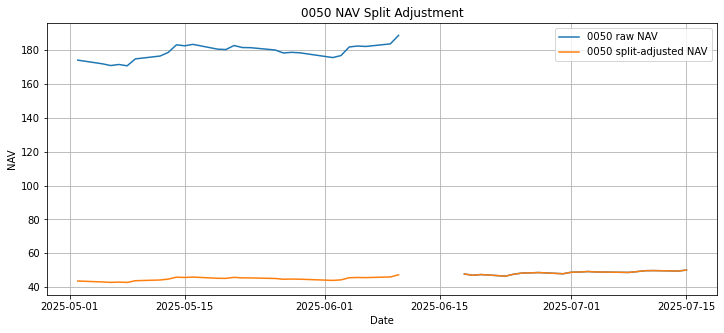

In [323]:
tmp = data.loc["2025-05-01":"2025-07-15"].copy()
x = tmp.index.to_numpy()

plt.figure(figsize=(12, 5))
plt.plot(x, tmp["nav_0050_raw"].to_numpy(), label="0050 raw NAV")
plt.plot(x, tmp["nav_0050"].to_numpy(), label="0050 split-adjusted NAV")
plt.title("0050 NAV Split Adjustment")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()
plt.grid(True)
plt.show()

### Drop NA 並檢查研究樣本

In [324]:
needed_cols = [
    f"price_{symbol_a}",
    f"price_{symbol_b}",
    f"nav_{symbol_a}",
    f"nav_{symbol_b}",
    f"premium_{symbol_a}",
    f"premium_{symbol_b}",
]

before_drop = len(data)

data = data.dropna(subset=needed_cols).copy()

after_drop = len(data)

print("Before dropna:", before_drop)
print("After dropna:", after_drop)
print("Dropped rows:", before_drop - after_drop)
print("Date range after dropna:", data.index.min(), "to", data.index.max())

data.head()

Before dropna: 571
After dropna: 566
Dropped rows: 5
Date range after dropna: 2024-01-02 00:00:00 to 2026-05-18 00:00:00


,price_0050,price_006208,close_0050,close_006208,nav_0050_raw,nav_006208_raw,premium_0050,premium_006208,volume_0050,volume_006208,nav_0050,nav_006208
date,,,,,,,,,,,,
2024-01-02,31.668650,73.336761,33.724998,76.900002,135.45,77.25,-0.0041,-0.0045,23688304,2839850,33.8625,77.25
2024-01-03,31.116974,72.096985,33.137501,75.599998,132.66,75.65,-0.0008,-0.0007,54189900,6382057,33.1650,75.65
2024-01-04,31.105234,72.049309,33.125000,75.550003,132.86,75.77,-0.0027,-0.0029,18270372,2976905,33.2150,75.77
2024-01-05,31.023071,71.858566,33.037498,75.349998,132.22,75.40,-0.0005,-0.0007,15998684,2577533,33.0550,75.40
2024-01-08,31.163923,72.383087,33.187500,75.900002,133.01,75.84,-0.0020,0.0008,37578880,4169890,33.2525,75.84


### 畫標準化價格與 NAV

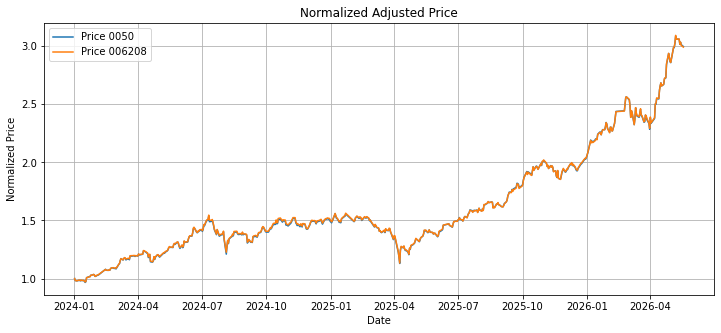

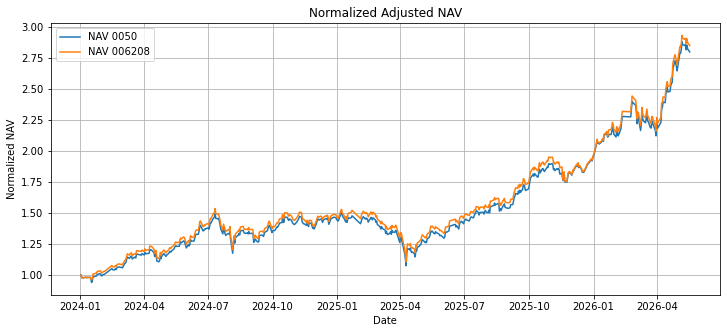

In [325]:
x = data.index.to_numpy()

price_norm_a = data[f"price_{symbol_a}"] / data[f"price_{symbol_a}"].iloc[0]
price_norm_b = data[f"price_{symbol_b}"] / data[f"price_{symbol_b}"].iloc[0]

plt.figure(figsize=(12, 5))
plt.plot(x, price_norm_a.to_numpy(), label=f"Price {symbol_a}")
plt.plot(x, price_norm_b.to_numpy(), label=f"Price {symbol_b}")
plt.title("Normalized Adjusted Price")
plt.xlabel("Date")
plt.ylabel("Normalized Price")
plt.legend()
plt.grid(True)
plt.show()

nav_norm_a = data[f"nav_{symbol_a}"] / data[f"nav_{symbol_a}"].iloc[0]
nav_norm_b = data[f"nav_{symbol_b}"] / data[f"nav_{symbol_b}"].iloc[0]

plt.figure(figsize=(12, 5))
plt.plot(x, nav_norm_a.to_numpy(), label=f"NAV {symbol_a}")
plt.plot(x, nav_norm_b.to_numpy(), label=f"NAV {symbol_b}")
plt.title("Normalized Adjusted NAV")
plt.xlabel("Date")
plt.ylabel("Normalized NAV")
plt.legend()
plt.grid(True)
plt.show()

### 估 rolling beta

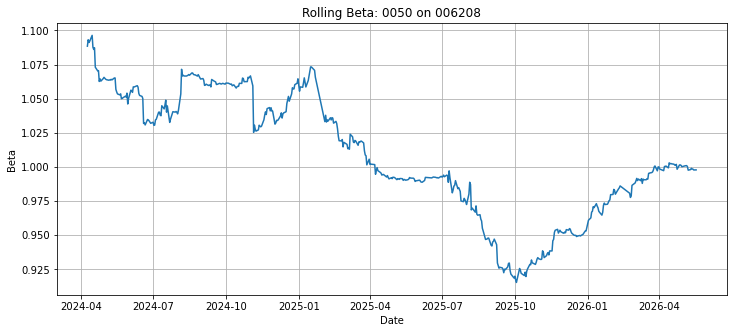

In [326]:
log_price_a = np.log(data[f"price_{symbol_a}"])
log_price_b = np.log(data[f"price_{symbol_b}"])

ret_a = log_price_a.diff()
ret_b = log_price_b.diff()

rolling_cov = ret_a.rolling(beta_window).cov(ret_b)
rolling_var = ret_b.rolling(beta_window).var()

data["beta"] = rolling_cov / rolling_var

data["beta"].describe()

plt.figure(figsize=(12, 5))
plt.plot(data.index.to_numpy(), data["beta"].to_numpy())
plt.title("Rolling Beta: 0050 on 006208")
plt.xlabel("Date")
plt.ylabel("Beta")
plt.grid(True)
plt.show()

### 計算 NAV-adjusted mispricing spread

Before spread dropna: 566
After spread dropna: 506
Dropped rows: 60


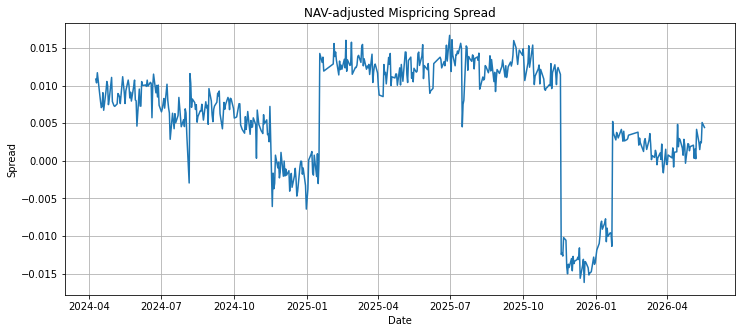

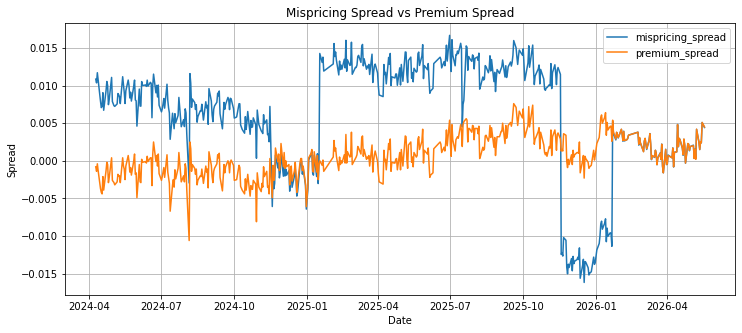

In [327]:
log_price_a = np.log(data[f"price_{symbol_a}"])
log_price_b = np.log(data[f"price_{symbol_b}"])

log_nav_a = np.log(data[f"nav_{symbol_a}"])
log_nav_b = np.log(data[f"nav_{symbol_b}"])

data["price_spread"] = log_price_a - data["beta"] * log_price_b
data["nav_spread"] = log_nav_a - data["beta"] * log_nav_b

data["mispricing_spread"] = data["price_spread"] - data["nav_spread"]

data["premium_spread"] = data[f"premium_{symbol_a}"] - data[f"premium_{symbol_b}"]

before_spread_drop = len(data)

data = data.dropna(
    subset=[
        "beta",
        "price_spread",
        "nav_spread",
        "mispricing_spread",
        "premium_spread",
    ]
).copy()

after_spread_drop = len(data)

print("Before spread dropna:", before_spread_drop)
print("After spread dropna:", after_spread_drop)
print("Dropped rows:", before_spread_drop - after_spread_drop)

plt.figure(figsize=(12, 5))
plt.plot(data.index.to_numpy(), data["mispricing_spread"].to_numpy())
plt.title("NAV-adjusted Mispricing Spread")
plt.xlabel("Date")
plt.ylabel("Spread")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(data.index.to_numpy(), data["mispricing_spread"].to_numpy(), label="mispricing_spread")
plt.plot(data.index.to_numpy(), data["premium_spread"].to_numpy(), label="premium_spread")
plt.title("Mispricing Spread vs Premium Spread")
plt.xlabel("Date")
plt.ylabel("Spread")
plt.legend()
plt.grid(True)
plt.show()

### 計算 z-score

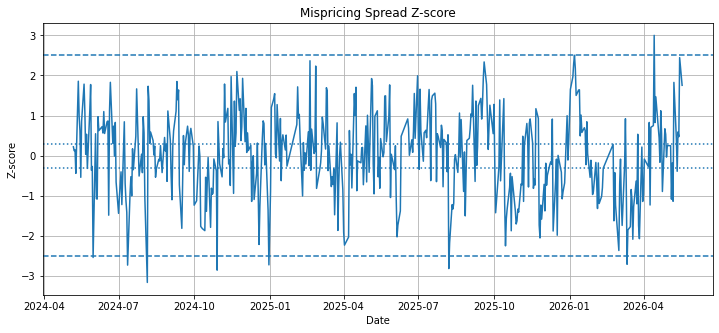

In [328]:
signal_col = "premium_spread"

data["spread_mean"] = data[signal_col].rolling(z_window).mean()
data["spread_std"] = data[signal_col].rolling(z_window).std()

data["z_score"] = (
    data[signal_col] - data["spread_mean"]
) / data["spread_std"]

data = data.dropna(subset=["z_score"]).copy()

data["z_score"].describe()

plt.figure(figsize=(12, 5))
plt.plot(data.index.to_numpy(), data["z_score"].to_numpy())
plt.axhline(entry_z, linestyle="--")
plt.axhline(-entry_z, linestyle="--")
plt.axhline(exit_z, linestyle=":")
plt.axhline(-exit_z, linestyle=":")
plt.title("Mispricing Spread Z-score")
plt.xlabel("Date")
plt.ylabel("Z-score")
plt.grid(True)
plt.show()

### 產生交易訊號

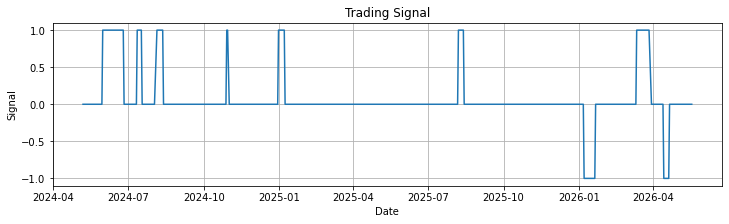

In [329]:
signals = []
current_pos = 0

for z in data["z_score"]:
    if pd.isna(z):
        signals.append(0)
        continue

    if current_pos == 0:
        if z > entry_z:
            current_pos = -1   # short 0050, long 006208
        elif z < -entry_z:
            current_pos = 1    # long 0050, short 006208
    else:
        if abs(z) < exit_z:
            current_pos = 0

    signals.append(current_pos)

data["signal"] = signals

data["signal"].value_counts()

plt.figure(figsize=(12, 3))
plt.plot(data.index.to_numpy(), data["signal"].to_numpy())
plt.title("Trading Signal")
plt.xlabel("Date")
plt.ylabel("Signal")
plt.grid(True)
plt.show()

### 回測策略報酬

In [330]:
data[f"ret_{symbol_a}"] = data[f"price_{symbol_a}"].pct_change()
data[f"ret_{symbol_b}"] = data[f"price_{symbol_b}"].pct_change()

# 避免偷看未來：今天 signal，明天才持有 position
data["position"] = data["signal"].shift(1).fillna(0)

# position = 1: long 0050, short 006208
# position = -1: short 0050, long 006208
sizing_mode = "beta_neutral"  # "dollar_neutral" or "beta_neutral"

if sizing_mode == "dollar_neutral":
    data["weight_a"] = 0.5
    data["weight_b"] = 0.5

elif sizing_mode == "beta_neutral":
    beta_abs = data["beta"].abs()

    data["weight_a"] = 1 / (1 + beta_abs)
    data["weight_b"] = beta_abs / (1 + beta_abs)

else:
    raise ValueError("sizing_mode must be dollar_neutral or beta_neutral")


# position = 1：long A, short B
# position = -1：short A, long B
data["gross_ret"] = data["position"] * (
    data["weight_a"] * data[f"ret_{symbol_a}"]
    - data["weight_b"] * data[f"ret_{symbol_b}"]
)

data["turnover"] = data["position"].diff().abs().fillna(0)

data["cost"] = data["turnover"] * fee_rate

data["strategy_ret"] = data["gross_ret"] - data["cost"]

data["equity"] = (1 + data["strategy_ret"].fillna(0)).cumprod()

data["peak"] = data["equity"].cummax()
data["drawdown"] = data["equity"] / data["peak"] - 1

### 績效指標

In [331]:
ret = data["strategy_ret"].dropna()
equity = data["equity"].dropna()

total_return = equity.iloc[-1] - 1
annual_return = equity.iloc[-1] ** (252 / len(data)) - 1
annual_vol = ret.std() * np.sqrt(252)
sharpe = annual_return / annual_vol if annual_vol != 0 else np.nan
max_drawdown = data["drawdown"].min()
trade_count = int((data["position"].diff().abs() > 0).sum())
exposure_ratio = (data["position"] != 0).mean()

active_ret = data.loc[data["position"] != 0, "strategy_ret"].dropna()

win_rate_active_days = (active_ret > 0).mean() if len(active_ret) > 0 else np.nan
avg_active_daily_return = active_ret.mean() if len(active_ret) > 0 else np.nan

metrics = {
    "total_return": total_return,
    "annual_return": annual_return,
    "annual_vol": annual_vol,
    "sharpe": sharpe,
    "max_drawdown": max_drawdown,
    "trade_count": trade_count,
    "exposure_ratio": exposure_ratio,
    "win_rate_active_days": win_rate_active_days,
    "avg_active_daily_return": avg_active_daily_return,
}

pd.Series(metrics).to_frame("value")

,value
total_return,-0.000939
annual_return,-0.000486
annual_vol,0.006335
sharpe,-0.076740
max_drawdown,-0.005994
trade_count,18.000000
exposure_ratio,0.135524
win_rate_active_days,0.469697
avg_active_daily_return,0.000095


### 畫策略結果

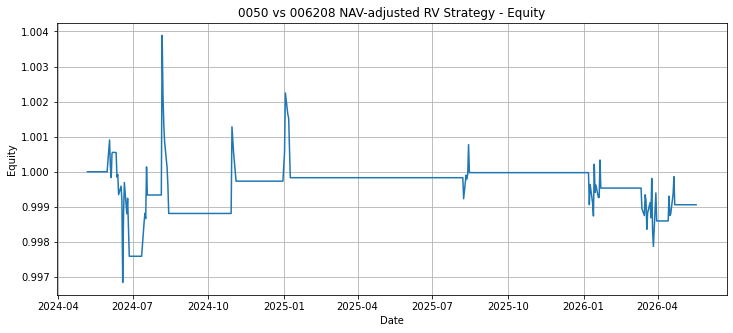

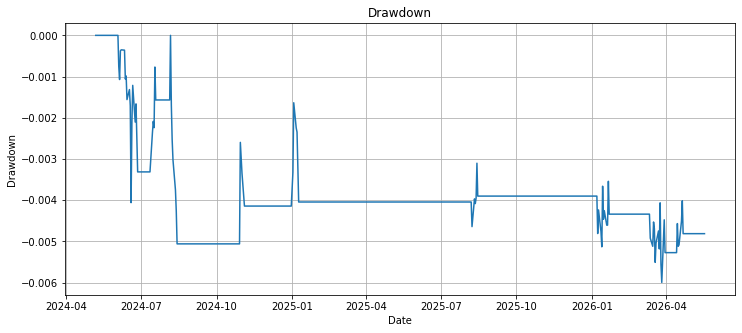

In [332]:
plt.figure(figsize=(12, 5))
plt.plot(data.index.to_numpy(), data["equity"].to_numpy())
plt.title("0050 vs 006208 NAV-adjusted RV Strategy - Equity")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(data.index.to_numpy(), data["drawdown"].to_numpy())
plt.title("Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.grid(True)
plt.show()

### 檢查交易事件

In [333]:
trades = data[data["position"].diff().abs() > 0].copy()

trades[
    [
        "z_score",
        "signal",
        "position",
        "mispricing_spread",
        "premium_spread",
        "strategy_ret",
        "equity",
    ]
].tail(30)

,z_score,signal,position,mispricing_spread,premium_spread,strategy_ret,equity
date,,,,,,,
2024-06-03,0.546651,1,1.0,0.009535,-0.0005,0.000908,1.000908
2024-06-27,0.828840,0,0.0,0.010066,0.0009,-0.000800,0.997592
2024-07-15,-0.927542,1,1.0,0.006322,-0.0032,0.000956,0.998545
2024-07-19,-0.351858,0,0.0,0.005066,-0.0024,-0.000800,0.999339
2024-08-06,1.731501,1,1.0,0.011591,0.0025,0.004554,1.003890
2024-08-14,0.240382,0,0.0,0.007458,-0.0011,-0.000800,0.998812
2024-10-30,0.850056,1,1.0,0.006745,-0.0016,0.002475,1.001284
2024-11-04,-0.529381,0,0.0,0.003991,-0.0041,-0.000800,0.999733
2025-01-02,-0.894806,1,1.0,-0.003739,-0.0032,0.000825,1.000558


### 輸出研究結果

In [334]:
OUTPUT_PATH = PROJECT_ROOT / "data" / "processed" / "strategies" / "strategy_0050_006208_rv_research.csv"

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

data.to_csv(
    OUTPUT_PATH,
    index=True,
    encoding="utf-8-sig",
)

OUTPUT_PATH

WindowsPath('C:/Users/USER/Desktop/ETF-alpha-lab/data/processed/strategies/strategy_0050_006208_rv_research.csv')

### 跑回測參數最佳化

In [335]:
def run_premium_spread_strategy(
    base_data: pd.DataFrame,
    symbol_a: str = "0050",
    symbol_b: str = "006208",
    z_window: int = 20,
    entry_z: float = 2.0,
    exit_z: float = 0.5,
    min_premium_spread: float = 0.0,
    fee_rate: float = 0.0008,
) -> tuple[pd.DataFrame, dict]:
    """
    Run premium-spread mean reversion strategy.

    Signal:
    - premium_spread z-score > entry_z:
        short symbol_a, long symbol_b
    - premium_spread z-score < -entry_z:
        long symbol_a, short symbol_b
    - abs(z-score) < exit_z:
        flat

    min_premium_spread:
    - absolute premium spread threshold
    - used to avoid trading tiny mispricing that cannot cover costs
    """

    data = base_data.copy()

    # 用 premium_spread 當主訊號
    signal_col = "premium_spread"

    data["spread_mean"] = data[signal_col].rolling(z_window).mean()
    data["spread_std"] = data[signal_col].rolling(z_window).std()

    data["z_score"] = (
        data[signal_col] - data["spread_mean"]
    ) / data["spread_std"]

    data = data.dropna(subset=["z_score", "premium_spread"]).copy()

    signals = []
    current_pos = 0

    for z, premium_spread in zip(data["z_score"], data["premium_spread"]):
        if pd.isna(z) or pd.isna(premium_spread):
            signals.append(0)
            continue

        enough_edge = abs(premium_spread) > min_premium_spread

        if current_pos == 0:
            if z > entry_z and enough_edge:
                # 0050 相對 006208 太貴
                # short 0050, long 006208
                current_pos = -1

            elif z < -entry_z and enough_edge:
                # 0050 相對 006208 太便宜
                # long 0050, short 006208
                current_pos = 1

        else:
            if abs(z) < exit_z:
                current_pos = 0

        signals.append(current_pos)

    data["signal"] = signals

    # 報酬計算
    data[f"ret_{symbol_a}"] = data[f"price_{symbol_a}"].pct_change()
    data[f"ret_{symbol_b}"] = data[f"price_{symbol_b}"].pct_change()

    # 避免偷看未來
    data["position"] = data["signal"].shift(1).fillna(0)

    data["gross_ret"] = (
        data["position"]
        * 0.5
        * (data[f"ret_{symbol_a}"] - data[f"ret_{symbol_b}"])
    )

    data["turnover"] = data["position"].diff().abs().fillna(0)
    data["cost"] = data["turnover"] * fee_rate
    data["strategy_ret"] = data["gross_ret"] - data["cost"]

    data["equity"] = (1 + data["strategy_ret"].fillna(0)).cumprod()
    data["peak"] = data["equity"].cummax()
    data["drawdown"] = data["equity"] / data["peak"] - 1

    ret = data["strategy_ret"].dropna()
    equity = data["equity"].dropna()

    if len(ret) == 0 or len(equity) == 0:
        metrics = {
            "total_return": np.nan,
            "annual_return": np.nan,
            "annual_vol": np.nan,
            "sharpe": np.nan,
            "max_drawdown": np.nan,
            "gross_return_sum": np.nan,
            "cost_sum": np.nan,
            "net_return_sum": np.nan,
            "trade_count": 0,
            "turnover_sum": 0,
            "exposure_ratio": 0,
        }

        return data, metrics

    total_return = equity.iloc[-1] - 1
    annual_return = equity.iloc[-1] ** (252 / len(data)) - 1
    annual_vol = ret.std() * np.sqrt(252)
    sharpe = annual_return / annual_vol if annual_vol != 0 else np.nan
    max_drawdown = data["drawdown"].min()

    trade_count = int((data["position"].diff().abs() > 0).sum())
    turnover_sum = data["turnover"].sum()
    exposure_ratio = (data["position"] != 0).mean()

    metrics = {
        "total_return": total_return,
        "annual_return": annual_return,
        "annual_vol": annual_vol,
        "sharpe": sharpe,
        "max_drawdown": max_drawdown,
        "gross_return_sum": data["gross_ret"].sum(),
        "cost_sum": data["cost"].sum(),
        "net_return_sum": data["strategy_ret"].sum(),
        "trade_count": trade_count,
        "turnover_sum": turnover_sum,
        "exposure_ratio": exposure_ratio,
    }

    return data, metrics

#設定參數範圍
entry_z_list = [1.5, 2.0, 2.5]
exit_z_list = [0.3, 0.5, 0.8]
min_premium_spread_list = [0.0000, 0.0010, 0.0015, 0.0020]
z_window_list = [20]

#批次跑參數測試
results = []

for z_window_i in z_window_list:
    for entry_z_i in entry_z_list:
        for exit_z_i in exit_z_list:
            for min_spread_i in min_premium_spread_list:

                # 避免 exit_z >= entry_z，這種邏輯不合理
                if exit_z_i >= entry_z_i:
                    continue

                bt, metrics = run_premium_spread_strategy(
                    base_data=data,
                    symbol_a=symbol_a,
                    symbol_b=symbol_b,
                    z_window=z_window_i,
                    entry_z=entry_z_i,
                    exit_z=exit_z_i,
                    min_premium_spread=min_spread_i,
                    fee_rate=fee_rate,
                )

                row = {
                    "z_window": z_window_i,
                    "entry_z": entry_z_i,
                    "exit_z": exit_z_i,
                    "min_premium_spread": min_spread_i,
                    **metrics,
                }

                results.append(row)

sensitivity = pd.DataFrame(results)

sensitivity = sensitivity.sort_values(
    ["total_return", "sharpe"],
    ascending=False,
).reset_index(drop=True)

sensitivity.head(20)

cols = [
    "z_window",
    "entry_z",
    "exit_z",
    "min_premium_spread",
    "total_return",
    "annual_return",
    "annual_vol",
    "sharpe",
    "max_drawdown",
    "gross_return_sum",
    "cost_sum",
    "net_return_sum",
    "trade_count",
    "turnover_sum",
    "exposure_ratio",
]

sensitivity[cols].head(20)

sensitivity["cost_to_gross"] = (
    sensitivity["cost_sum"] / sensitivity["gross_return_sum"].replace(0, np.nan)
)

sensitivity["net_to_gross"] = (
    sensitivity["net_return_sum"] / sensitivity["gross_return_sum"].replace(0, np.nan)
)

sensitivity[[
    "entry_z",
    "exit_z",
    "min_premium_spread",
    "gross_return_sum",
    "cost_sum",
    "net_return_sum",
    "cost_to_gross",
    "net_to_gross",
    "trade_count",
    "exposure_ratio",
    "sharpe",
    "max_drawdown",
]].sort_values("net_return_sum", ascending=False).head(20)

,entry_z,exit_z,min_premium_spread,gross_return_sum,cost_sum,net_return_sum,cost_to_gross,net_to_gross,trade_count,exposure_ratio,sharpe,max_drawdown
0,2.5,0.3,0.0010,0.016106,0.0096,0.006506,0.596034,0.403966,12,0.068376,0.579116,-0.003196
2,2.5,0.3,0.0020,0.016106,0.0096,0.006506,0.596034,0.403966,12,0.068376,0.579116,-0.003196
1,2.5,0.3,0.0015,0.016106,0.0096,0.006506,0.596034,0.403966,12,0.068376,0.579116,-0.003196
3,2.5,0.5,0.0010,0.015440,0.0096,0.005840,0.621776,0.378224,12,0.049145,0.530054,-0.003196
4,2.5,0.5,0.0015,0.015440,0.0096,0.005840,0.621776,0.378224,12,0.049145,0.530054,-0.003196
5,2.5,0.5,0.0020,0.015440,0.0096,0.005840,0.621776,0.378224,12,0.049145,0.530054,-0.003196
6,2.5,0.3,0.0000,0.018373,0.0128,0.005573,0.696687,0.303313,16,0.104701,0.459784,-0.003747
8,2.5,0.8,0.0015,0.014816,0.0096,0.005216,0.647954,0.352046,12,0.044872,0.478384,-0.003196
9,2.5,0.8,0.0020,0.014816,0.0096,0.005216,0.647954,0.352046,12,0.044872,0.478384,-0.003196
7,2.5,0.8,0.0010,0.014816,0.0096,0.005216,0.647954,0.352046,12,0.044872,0.478384,-0.003196


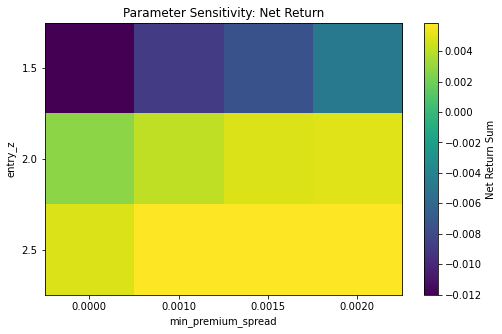

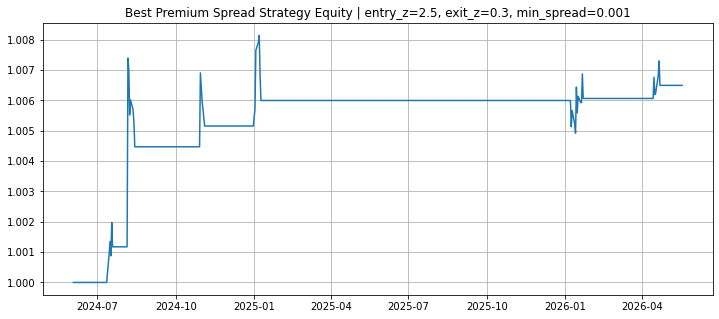

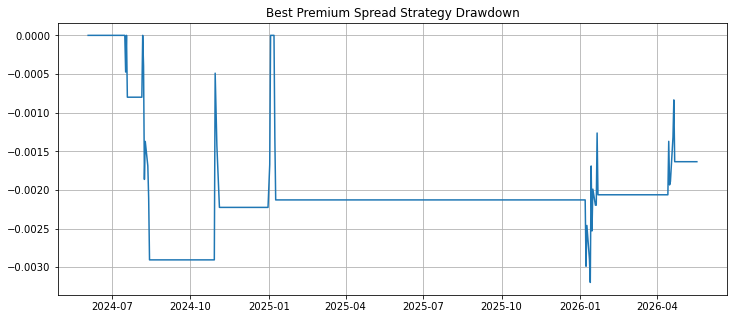

In [336]:
heat_data = sensitivity[
    sensitivity["exit_z"] == 0.5
].copy()

heat_table = heat_data.pivot_table(
    index="entry_z",
    columns="min_premium_spread",
    values="net_return_sum",
    aggfunc="mean",
)

heat_table

plt.figure(figsize=(8, 5))
plt.imshow(heat_table.to_numpy(), aspect="auto")
plt.colorbar(label="Net Return Sum")
plt.xticks(
    ticks=np.arange(len(heat_table.columns)),
    labels=[f"{x:.4f}" for x in heat_table.columns],
)
plt.yticks(
    ticks=np.arange(len(heat_table.index)),
    labels=[f"{x:.1f}" for x in heat_table.index],
)
plt.xlabel("min_premium_spread")
plt.ylabel("entry_z")
plt.title("Parameter Sensitivity: Net Return")
plt.show()

best = sensitivity.iloc[0]

best

best_data, best_metrics = run_premium_spread_strategy(
    base_data=data,
    symbol_a=symbol_a,
    symbol_b=symbol_b,
    z_window=int(best["z_window"]),
    entry_z=float(best["entry_z"]),
    exit_z=float(best["exit_z"]),
    min_premium_spread=float(best["min_premium_spread"]),
    fee_rate=fee_rate,
)

pd.Series(best_metrics).to_frame("value")

plt.figure(figsize=(12, 5))
plt.plot(best_data.index.to_numpy(), best_data["equity"].to_numpy())
plt.title(
    f"Best Premium Spread Strategy Equity | "
    f"entry_z={best['entry_z']}, exit_z={best['exit_z']}, "
    f"min_spread={best['min_premium_spread']}"
)
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(best_data.index.to_numpy(), best_data["drawdown"].to_numpy())
plt.title("Best Premium Spread Strategy Drawdown")
plt.grid(True)
plt.show()

In [337]:
sensitivity[[
    "z_window",
    "entry_z",
    "exit_z",
    "min_premium_spread",
    "gross_return_sum",
    "cost_sum",
    "net_return_sum",
    "trade_count",
    "exposure_ratio",
    "sharpe",
    "max_drawdown",
    "cost_to_gross",
    "net_to_gross",
]].sort_values("net_return_sum", ascending=False).head(10)

,z_window,entry_z,exit_z,min_premium_spread,gross_return_sum,cost_sum,net_return_sum,trade_count,exposure_ratio,sharpe,max_drawdown,cost_to_gross,net_to_gross
0,20,2.5,0.3,0.0010,0.016106,0.0096,0.006506,12,0.068376,0.579116,-0.003196,0.596034,0.403966
2,20,2.5,0.3,0.0020,0.016106,0.0096,0.006506,12,0.068376,0.579116,-0.003196,0.596034,0.403966
1,20,2.5,0.3,0.0015,0.016106,0.0096,0.006506,12,0.068376,0.579116,-0.003196,0.596034,0.403966
3,20,2.5,0.5,0.0010,0.015440,0.0096,0.005840,12,0.049145,0.530054,-0.003196,0.621776,0.378224
4,20,2.5,0.5,0.0015,0.015440,0.0096,0.005840,12,0.049145,0.530054,-0.003196,0.621776,0.378224
5,20,2.5,0.5,0.0020,0.015440,0.0096,0.005840,12,0.049145,0.530054,-0.003196,0.621776,0.378224
6,20,2.5,0.3,0.0000,0.018373,0.0128,0.005573,16,0.104701,0.459784,-0.003747,0.696687,0.303313
8,20,2.5,0.8,0.0015,0.014816,0.0096,0.005216,12,0.044872,0.478384,-0.003196,0.647954,0.352046
9,20,2.5,0.8,0.0020,0.014816,0.0096,0.005216,12,0.044872,0.478384,-0.003196,0.647954,0.352046
7,20,2.5,0.8,0.0010,0.014816,0.0096,0.005216,12,0.044872,0.478384,-0.003196,0.647954,0.352046
